In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# **Complete Case Analysis:**

Remove entire row where even one value is NULL in any one column of that row

Not used much

Used when the data is missing at random

Advantages:

1) Easy to implement

2) Preserves variable distribution

Disadvantages:

1) Can lose data if lot of it is missing

2) In production, model doesnt know how to handle missing values

Use when missing data < 5%

In [3]:
data = pd.read_csv("data_science_job.csv")

In [4]:
data.sample(5)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
6870,590,city_103,0.920,Male,No relevent experience,Full time course,Graduate,STEM,14.0,NaN,NaN,12.0,0.0
10722,32985,city_103,0.920,Male,No relevent experience,Full time course,Masters,STEM,19.0,NaN,Public Sector,21.0,1.0
9789,21178,city_65,0.802,Male,Has relevent experience,no_enrollment,Graduate,STEM,4.0,NaN,NaN,15.0,0.0
7880,16031,city_114,0.926,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,10000+,Pvt Ltd,42.0,0.0
7684,22693,city_90,0.698,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,NaN,NaN,6.0,0.0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  18679 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  float64
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  training_hours          18392 non-null  float64
 12  target                  19158 non-null  float64
dtypes: float64(4), int64(1), object(8)
memory usage: 1.9+ MB


In [6]:
data.shape[0]

19158

In [7]:
data.isna().sum()

,0
enrollee_id,0
city,0
city_development_index,479
gender,4508
relevent_experience,0
enrolled_university,386
education_level,460
major_discipline,2813
experience,65
company_size,5938


In [8]:
data.isna().mean()*100

,0
enrollee_id,0.000000
city,0.000000
city_development_index,2.500261
gender,23.530640
relevent_experience,0.000000
enrolled_university,2.014824
education_level,2.401086
major_discipline,14.683161
experience,0.339284
company_size,30.994885


In [9]:
# Identify column names with missing values < 5%

col = [col for col in data.columns if data[col].isna().mean() < 0.05 and data[col].isna().mean() > 0]
col

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [10]:
data[col].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
3315,0.910,no_enrollment,Graduate,8.0,82.0
15272,0.624,no_enrollment,Graduate,1.0,68.0
18416,0.624,Full time course,Graduate,2.0,264.0
12075,0.924,Full time course,High School,4.0,13.0
12942,0.796,Full time course,Primary School,2.0,11.0


In [11]:
# check how many rows will be still safe if we remove nulls from these cols
len(data[col].dropna()) / len(data)

0.8968577095730244

In [12]:
new_data = data[col].dropna()
print(len(new_data))
print(len(data))

17182
19158


In [13]:
new_data.sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
8424,0.910,no_enrollment,Masters,1.0,202.0
1949,0.897,no_enrollment,Masters,5.0,8.0
2033,0.920,no_enrollment,Graduate,7.0,39.0
1223,0.897,no_enrollment,Masters,11.0,56.0
3860,0.920,Full time course,Graduate,2.0,48.0


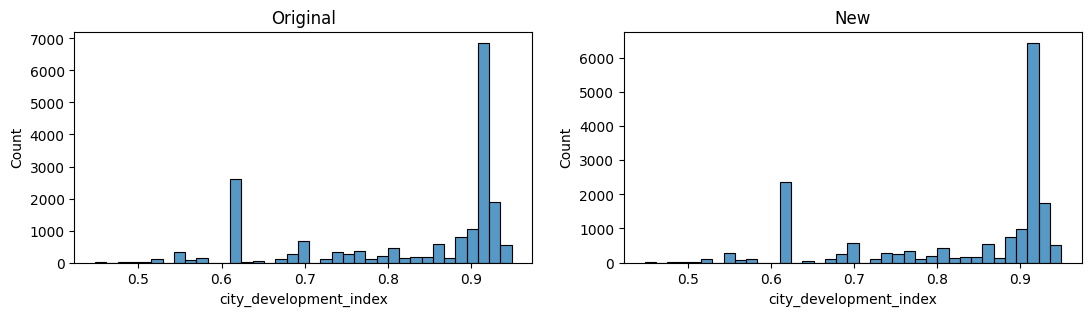

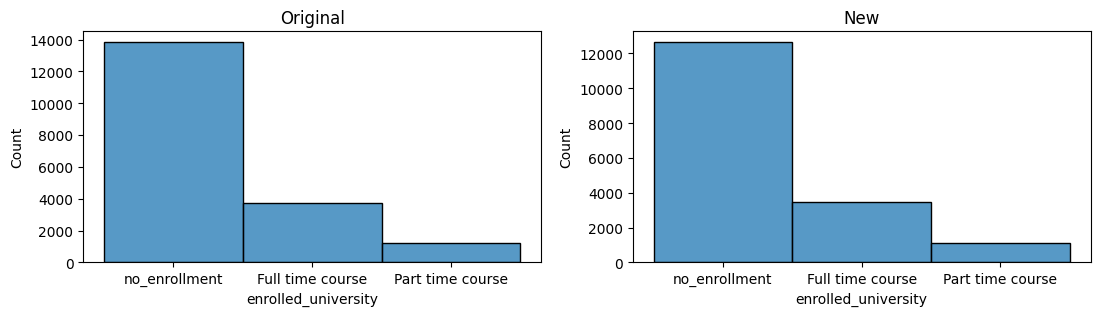

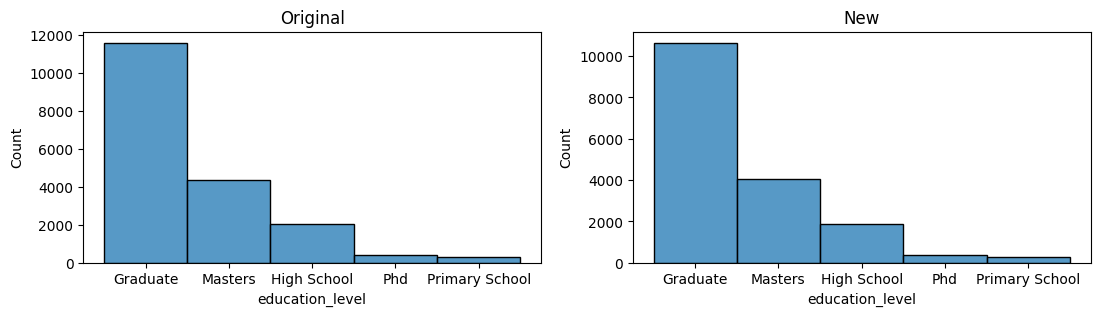

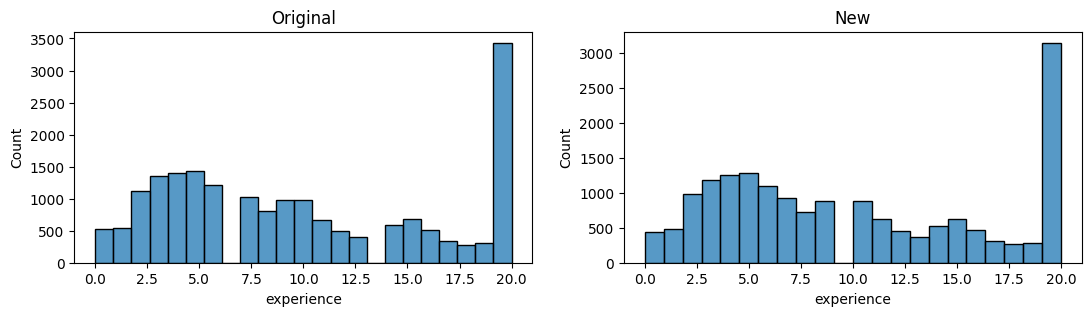

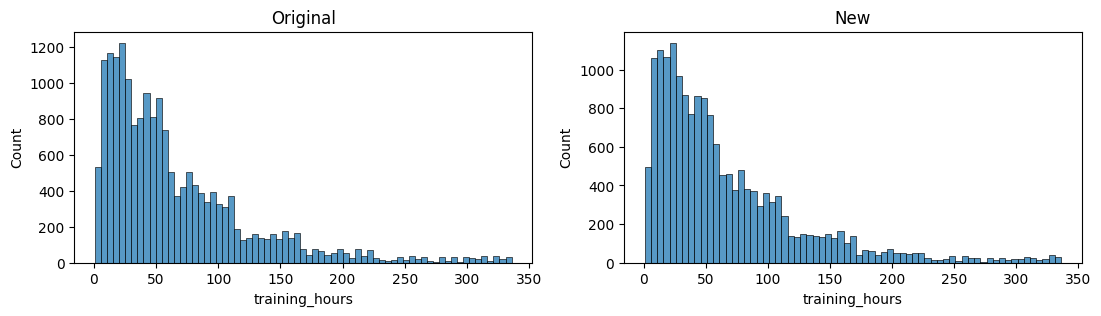

In [14]:
# checking histograms of new and old data to check changes if any

for column in col:

  plt.figure(figsize=(13,3))

  plt.subplot(121)
  sns.histplot(data[column])
  plt.title("Original")

  plt.subplot(122)
  sns.histplot(new_data[column])
  plt.title("New")

  plt.show()

# **Handling Numerical Missing Values**

# Univariate methods

1) Replace with Mean/Median


*   Replace with mean when normal data
*   Replace with median when skewed data


Advantages:

      a) Simple to implement
      b) Usable for missing < 5%

Disadvantages:

      a) Changes distribution shape
      b) Can create outliers
      c) Co-relation between columns changes

When to use:

    a) Data missing at random
    b) < 5% missing

In [15]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

In [16]:
data = pd.read_csv("titanic_toy.csv")
data.sample(5)

,Age,Fare,Family,Survived
496,54.00,78.2667,1,1
745,70.00,71.0000,2,0
808,39.00,13.0000,0,0
644,0.75,19.2583,3,1
721,17.00,7.0542,1,0


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [18]:
data.isna().sum()

,0
Age,177
Fare,45
Family,0
Survived,0


In [19]:
data.isna().mean() * 100

,0
Age,19.865320
Fare,5.050505
Family,0.000000
Survived,0.000000


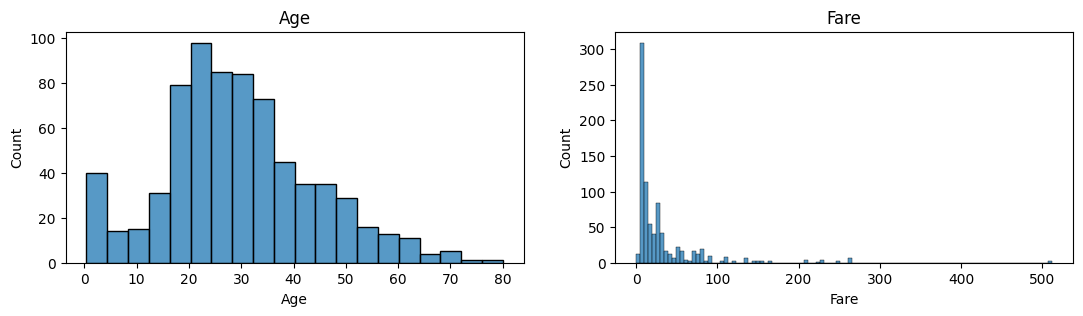

In [20]:
plt.figure(figsize=(13,3))

plt.subplot(121)
sns.histplot(data["Age"])
plt.title("Age")

plt.subplot(122)
sns.histplot(data["Fare"])
plt.title("Fare")

plt.show()

In [21]:
X_train, X_test, y_train, y_test = train_test_split(data.drop("Survived",axis=1), data["Survived"], test_size=0.2, random_state=3)

In [22]:
X_train.sample(5)

,Age,Fare,Family
587,60.0,79.200,2
244,30.0,7.225,0
95,NaN,8.050,0
612,NaN,15.500,1
320,22.0,7.250,0


In [23]:
imputer_mean = SimpleImputer(strategy="mean")

In [24]:
X_train_new = imputer_mean.fit_transform(X_train)
X_test_new = imputer_mean.transform(X_test)

In [25]:
X_train_new = pd.DataFrame(X_train_new, columns=X_train.columns)
X_test_new = pd.DataFrame(X_train_new, columns=X_test.columns)

In [26]:
X_train_new.head()

,Age,Fare,Family
0,27.0,7.795800,0.0
1,58.0,146.520800,0.0
2,18.0,7.495800,0.0
3,26.0,78.850000,0.0
4,22.0,31.944715,0.0


In [27]:
X_train.head()

,Age,Fare,Family
146,27.0,7.7958,0
195,58.0,146.5208,0
786,18.0,7.4958,0
290,26.0,78.8500,0
521,22.0,NaN,0


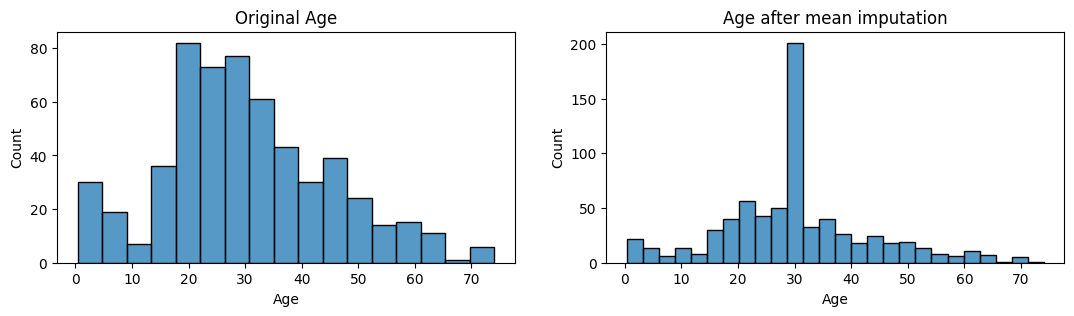

In [28]:
plt.figure(figsize=(13,3))

plt.subplot(121)
sns.histplot(X_train["Age"])
plt.title("Original Age")

plt.subplot(122)
sns.histplot(X_train_new["Age"])
plt.title("Age after mean imputation")

plt.show()

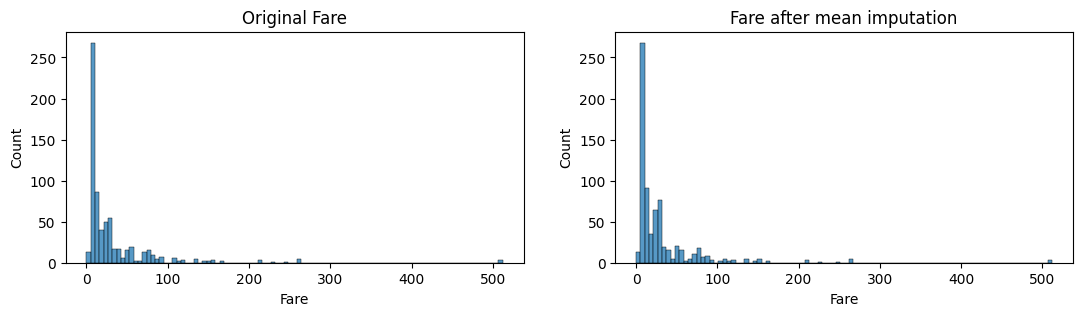

In [29]:
plt.figure(figsize=(13,3))

plt.subplot(121)
sns.histplot(X_train["Fare"])
plt.title("Original Fare")

plt.subplot(122)
sns.histplot(X_train_new["Fare"])
plt.title("Fare after mean imputation")

plt.show()

In [30]:
imputer_median = SimpleImputer(strategy="median")

In [31]:
X_train_new = imputer_mean.fit_transform(X_train)
X_test_new = imputer_mean.transform(X_test)

In [32]:
X_train_new = pd.DataFrame(X_train_new, columns=X_train.columns)
X_test_new = pd.DataFrame(X_train_new, columns=X_test.columns)

In [33]:
X_train_new.head()

,Age,Fare,Family
0,27.0,7.795800,0.0
1,58.0,146.520800,0.0
2,18.0,7.495800,0.0
3,26.0,78.850000,0.0
4,22.0,31.944715,0.0


In [34]:
X_train.head()

,Age,Fare,Family
146,27.0,7.7958,0
195,58.0,146.5208,0
786,18.0,7.4958,0
290,26.0,78.8500,0
521,22.0,NaN,0


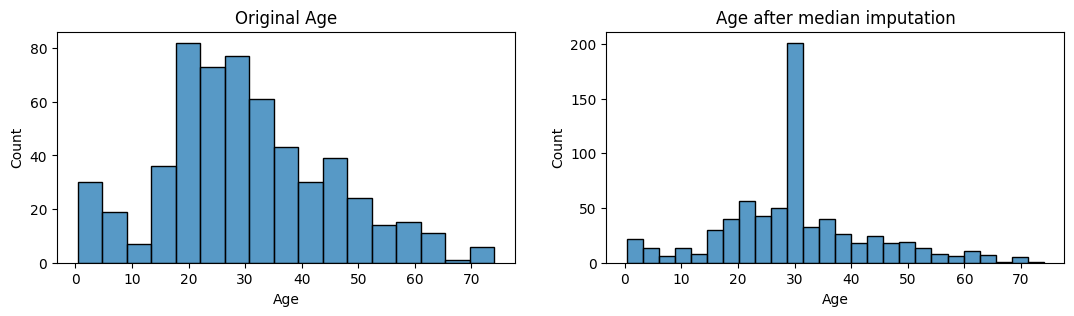

In [35]:
plt.figure(figsize=(13,3))

plt.subplot(121)
sns.histplot(X_train["Age"])
plt.title("Original Age")

plt.subplot(122)
sns.histplot(X_train_new["Age"])
plt.title("Age after median imputation")

plt.show()

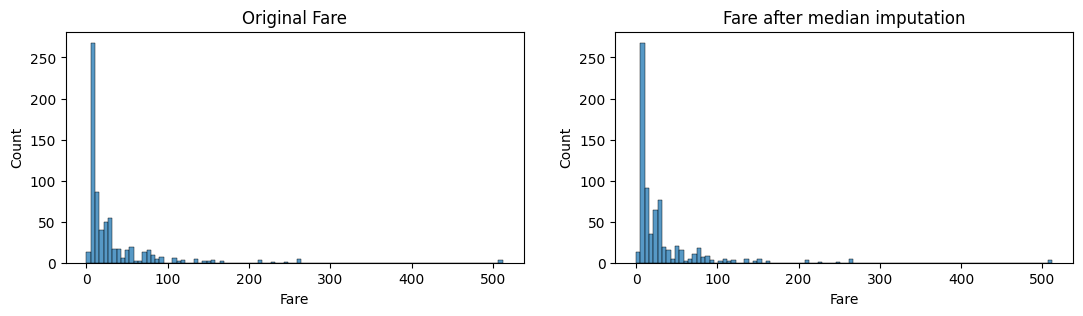

In [36]:
plt.figure(figsize=(13,3))

plt.subplot(121)
sns.histplot(X_train["Fare"])
plt.title("Original Fare")

plt.subplot(122)
sns.histplot(X_train_new["Fare"])
plt.title("Fare after median imputation")

plt.show()

<Axes: >

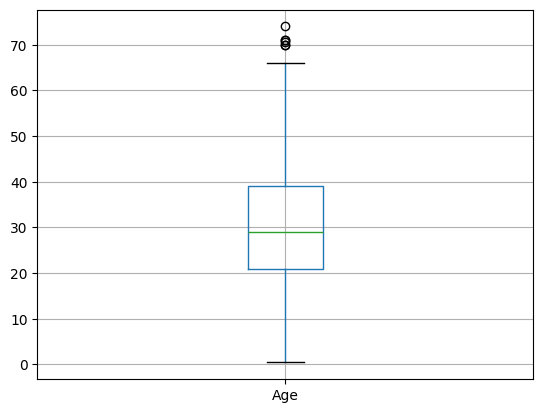

In [37]:
X_train[["Age"]].boxplot()

<Axes: >

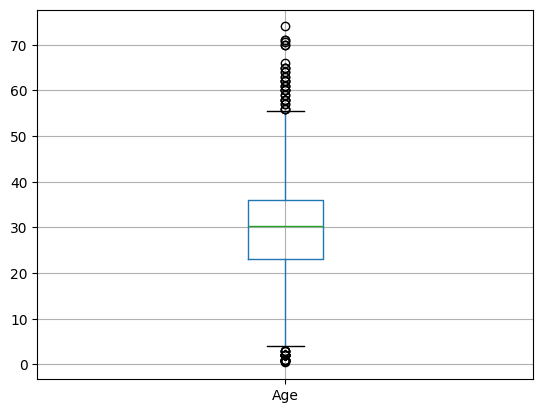

In [38]:
X_train_new[["Age"]].boxplot()

2) Replace with an Arbitrary Number that doesnt already exist in the data

Advantages:

      a) Simple to implement

Disadvantages:

      a) Changes distribution shape
      b) Can create outliers
      c) Co-relation between columns changes

Used when:

    a) Data is not missing at random

Not used much

In [39]:
X_train, X_test, y_train, y_test = train_test_split(data.drop("Survived",axis=1), data["Survived"], test_size=0.2, random_state=3)

In [40]:
X_train.isna().sum()

,0
Age,144
Fare,37
Family,0


In [41]:
X_test.isna().sum()

,0
Age,33
Fare,8
Family,0


In [42]:
X_train["Age_new"] = X_train["Age"].fillna(-1)
X_train["Fare_new"] = X_train["Fare"].fillna(-1)

In [43]:
X_train.sample(10)

,Age,Fare,Family,Age_new,Fare_new
219,30.0,10.5000,0,30.0,10.5000
265,36.0,10.5000,0,36.0,10.5000
426,28.0,26.0000,1,28.0,26.0000
209,40.0,31.0000,0,40.0,31.0000
312,26.0,26.0000,2,26.0,26.0000
857,51.0,26.5500,0,51.0,26.5500
704,26.0,7.8542,1,26.0,7.8542
289,22.0,7.7500,0,22.0,7.7500
95,NaN,8.0500,0,-1.0,8.0500
471,38.0,8.6625,0,38.0,8.6625


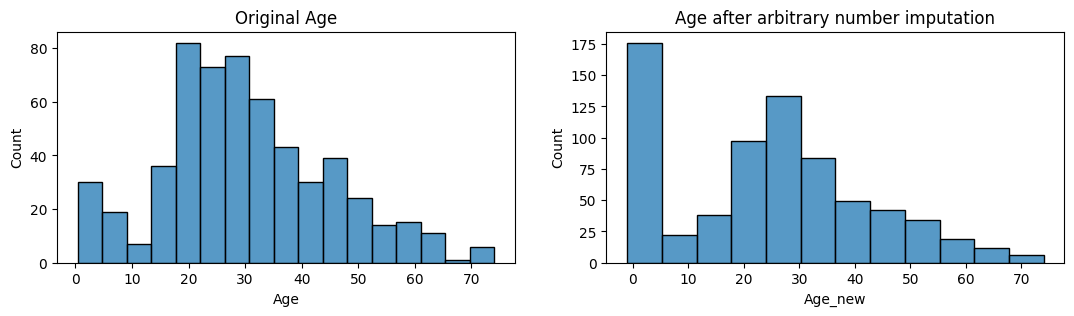

In [44]:
plt.figure(figsize=(13,3))

plt.subplot(121)
sns.histplot(X_train["Age"])
plt.title("Original Age")

plt.subplot(122)
sns.histplot(X_train["Age_new"])
plt.title("Age after arbitrary number imputation")

plt.show()

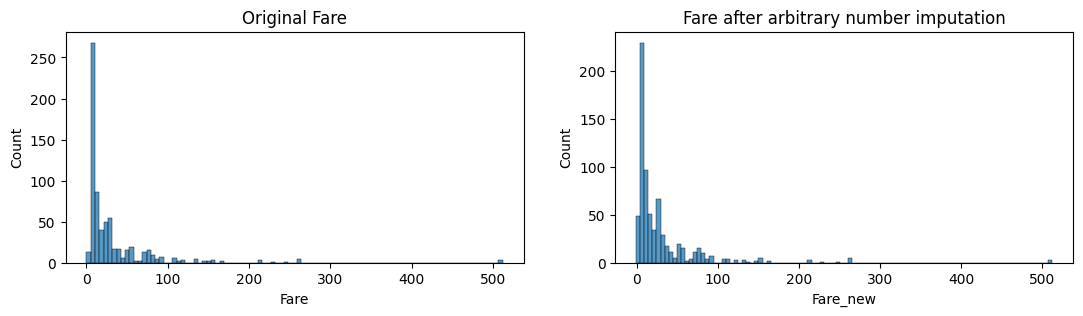

In [45]:
plt.figure(figsize=(13,3))

plt.subplot(121)
sns.histplot(X_train["Fare"])
plt.title("Original Fare")

plt.subplot(122)
sns.histplot(X_train["Fare_new"])
plt.title("Fare after arbitrary number imputation")

plt.show()

# **Handling Categorical Missing Values**


In [46]:
data = pd.read_csv("housing.csv", usecols=["GarageQual","FireplaceQu","SalePrice"])

In [47]:
data.sample(5)

,FireplaceQu,GarageQual,SalePrice
1222,Gd,TA,143000
338,NaN,TA,202500
820,NaN,TA,183000
69,TA,TA,225000
943,NaN,TA,143000


In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   FireplaceQu  770 non-null    object
 1   GarageQual   1379 non-null   object
 2   SalePrice    1460 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 34.3+ KB


In [51]:
data["GarageQual"].unique()

array(['TA', 'Fa', 'Gd', nan, 'Ex', 'Po'], dtype=object)

In [52]:
data["FireplaceQu"].unique()

array([nan, 'TA', 'Gd', 'Fa', 'Ex', 'Po'], dtype=object)

In [49]:
data.isna().sum()

,0
FireplaceQu,690
GarageQual,81
SalePrice,0


# 1) Replace with Most Frequent value


Advantages:

      a) Simple to implement
      b) Usable for missing < 5%

Disadvantages:

      a) Changes distribution shape
      b) Can create outliers
      c) Co-relation between columns changes

When to use:

    a) Data missing at random
    b) < 5% missing

In [50]:
X_train, X_test, y_train, y_test = train_test_split(data.drop("SalePrice",axis=1), data["SalePrice"], test_size=0.2, random_state=23)

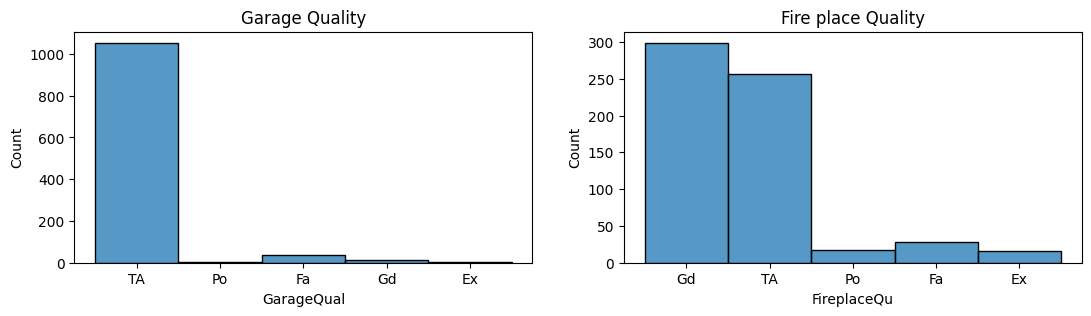

In [55]:
plt.figure(figsize=(13,3))

plt.subplot(121)
sns.histplot(X_train["GarageQual"])
plt.title("Garage Quality")

plt.subplot(122)
sns.histplot(X_train["FireplaceQu"])
plt.title("Fire place Quality")

plt.show()

In [56]:
X_train["GarageQual"].mode()

,GarageQual
0,TA


In [57]:
X_train["FireplaceQu"].mode()

,FireplaceQu
0,Gd


In [60]:
imputer = SimpleImputer(strategy="most_frequent")

In [61]:
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [64]:
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_train.columns)

In [65]:
X_train_imputed

,FireplaceQu,GarageQual
0,Gd,TA
1,Gd,TA
2,Gd,TA
3,Gd,TA
4,TA,TA
...,...,...
1163,Gd,TA
1164,Gd,TA
1165,Po,TA
1166,Gd,TA


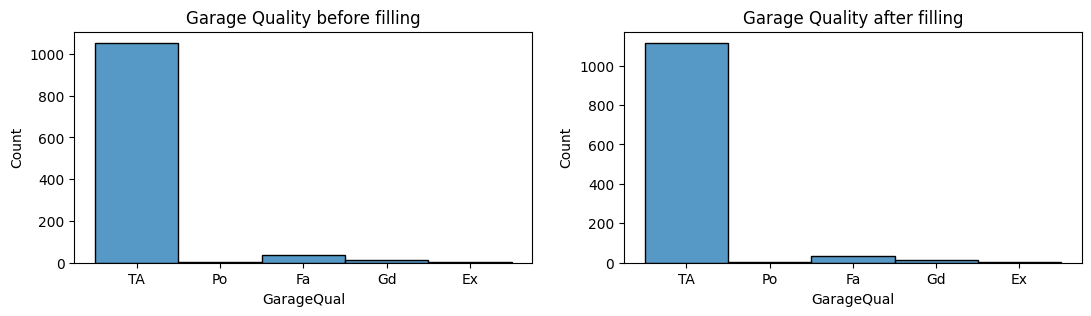

In [66]:
plt.figure(figsize=(13,3))

plt.subplot(121)
sns.histplot(X_train["GarageQual"])
plt.title("Garage Quality before filling")

plt.subplot(122)
sns.histplot(X_train_imputed["GarageQual"])
plt.title("Garage Quality after filling")

plt.show()

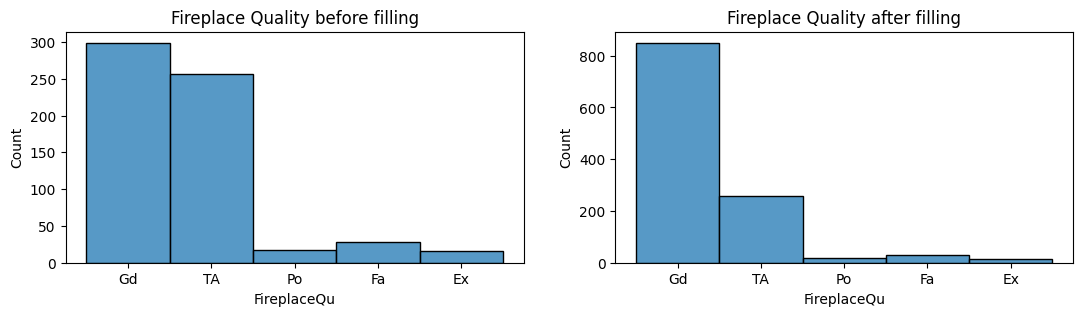

In [67]:
plt.figure(figsize=(13,3))

plt.subplot(121)
sns.histplot(X_train["FireplaceQu"])
plt.title("Fireplace Quality before filling")

plt.subplot(122)
sns.histplot(X_train_imputed["FireplaceQu"])
plt.title("Fireplace Quality after filling")

plt.show()

In [75]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)

2. Replace with string "Missing"

Use when NaN > 5%

In [76]:
X_train, X_test, y_train, y_test = train_test_split(data.drop("SalePrice",axis=1), data["SalePrice"], test_size=0.2, random_state=23)

In [77]:
X_train_new = X_train.fillna("Missing")
X_test_new = X_test.fillna("Missing")

In [78]:
X_train_new

,FireplaceQu,GarageQual
1290,Gd,TA
793,Missing,TA
83,Missing,TA
432,Missing,TA
929,TA,TA
...,...,...
31,Missing,TA
950,Missing,TA
1064,Po,TA
742,Missing,TA


In [82]:
X_train["GarageQual"].value_counts()

,count
GarageQual,
TA,1054
Fa,35
Gd,12
Po,3
Ex,2


In [81]:
X_train_new["GarageQual"].value_counts()

,count
GarageQual,
TA,1054
Missing,62
Fa,35
Gd,12
Po,3
Ex,2


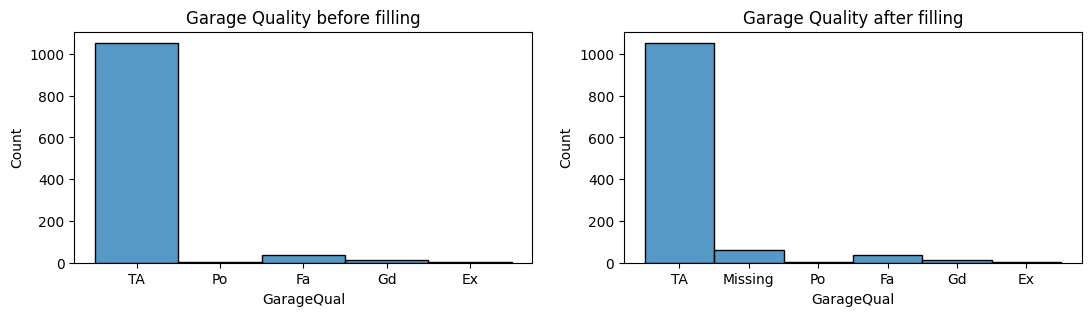

In [84]:
plt.figure(figsize=(13,3))

plt.subplot(121)
sns.histplot(X_train["GarageQual"])
plt.title("Garage Quality before filling")

plt.subplot(122)
sns.histplot(X_train_new["GarageQual"])
plt.title("Garage Quality after filling")

plt.show()

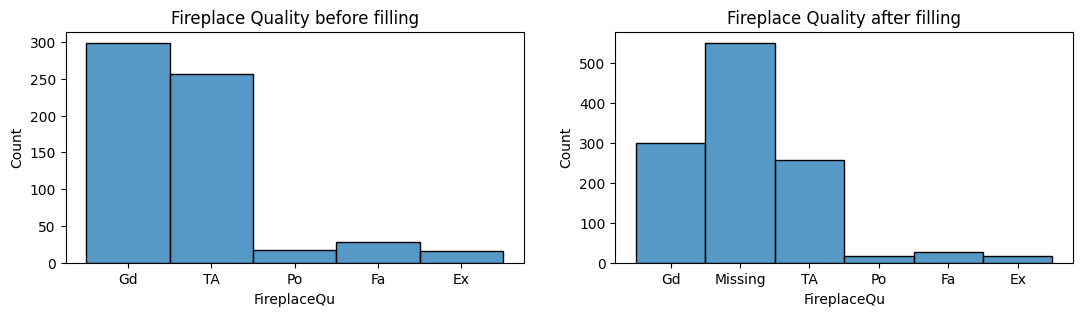

In [85]:
plt.figure(figsize=(13,3))

plt.subplot(121)
sns.histplot(X_train["FireplaceQu"])
plt.title("Fireplace Quality before filling")

plt.subplot(122)
sns.histplot(X_train_new["FireplaceQu"])
plt.title("Fireplace Quality after filling")

plt.show()

In [86]:
# For SimpleImputer, use SimpleImputer(strategy="constant",fill_value="Missing")